# 1. Imports

In [1]:
!pip install vaderSentiment sentence-transformers --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    confusion_matrix,
    precision_recall_curve,
    auc,
    accuracy_score
)

import catboost as cb
import optuna
from optuna.samplers import TPESampler

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.4 MB/s eta 0:00:00


# 2. LOAD DATASET & PREPROCESS

In [2]:
# 2. LOAD DATASET & PREPROCESS
# --- Load NLP tools once ---
vader = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    return vader.polarity_scores(str(text)[:1000])["compound"]

# ── Dataset Load ───────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/advaithsrao/enron-fraud-email-dataset/enron_data_fraud_labeled.csv'

df = pd.read_csv(DATA_PATH)
print("✅ Real Dataset loaded successfully!")
print(f"Available columns in the CSV: {df.columns.tolist()}")

text_candidates   = ['Text', 'text', 'Message', 'message', 'content', 'Content', 'body', 'Body', 'email', 'Email']
target_candidates = ['Class', 'class', 'Label', 'label', 'Fraud', 'fraud', 'is_fraud', 'target', 'Target']
TEXT_COL   = next((col for col in text_candidates   if col in df.columns), df.columns[0])
TARGET_COL = next((col for col in target_candidates if col in df.columns), df.columns[-1])

print(f"➡️  Auto-selected Text Column:   '{TEXT_COL}'")
print(f"➡️  Auto-selected Target Column: '{TARGET_COL}'\n")

df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)

meta_candidates = [
    'Subject', 'From', 'To', 'Date', 'Sender-Type',
    'Unique-Mails-From-Sender', 'Content-Type', 'Time', 'Suspicious-Folders',
    'Contains-Reply-Forwards'
]
available_meta = [col for col in meta_candidates if col in df.columns]

text_cols = [TEXT_COL]
if 'Subject' in available_meta:
    text_cols.append('Subject')
cat_cols = [col for col in available_meta if col != 'Subject']

for col in text_cols:
    df[col] = df[col].fillna("")
for col in cat_cols:
    df[col] = df[col].fillna("Missing").astype(str)

# ── NLP Meta-Features BEFORE lowercasing ──────────────────────────────────────
# ✅ Must run on original casing — spaCy NER needs proper caps
print("⏳ Computing NLP meta-features on original text (before preprocessing)...")
_raw_body = df[TEXT_COL].copy()   # original casing preserved

df['nlp_vader_compound'] = _raw_body.apply(vader_compound)

print("✅ NLP meta-feature added.")
print(f"   vader_compound — fraud mean: {df[df[TARGET_COL]==1]['nlp_vader_compound'].mean():.4f} "
      f"| legit mean: {df[df[TARGET_COL]==0]['nlp_vader_compound'].mean():.4f}")

# ── Text Preprocessing (AFTER NLP features) ───────────────────────────────────
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<[^>]*>', '', text)
    return text.strip()

for col in text_cols:
    df[col] = df[col].apply(preprocess_text)

print("✅ Text preprocessing done.")
nlp_num_cols  = ['nlp_vader_compound']
base_features = text_cols + cat_cols + nlp_num_cols
X_base = df[base_features]
y      = df[TARGET_COL]

X_train_base, X_temp_base, y_train, y_temp = train_test_split(
    X_base, y, test_size=0.3, stratify=y, random_state=42
)
X_val_base, X_test_base, y_val, y_test = train_test_split(
    X_temp_base, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print(f"Split → Train: {len(X_train_base)} | Val: {len(X_val_base)} | Test: {len(X_test_base)}")

✅ Real Dataset loaded successfully!
Available columns in the CSV: ['Folder-User', 'Folder-Name', 'Message-ID', 'Date', 'From', 'To', 'Subject', 'Mime-Version', 'Content-Type', 'Content-Transfer-Encoding', 'X-From', 'X-To', 'X-cc', 'X-bcc', 'X-Folder', 'X-Origin', 'X-FileName', 'Body', 'Cc', 'Bcc', 'Time', 'Attendees', 'Re', 'Source', 'Mail-ID', 'POI-Present', 'Suspicious-Folders', 'Sender-Type', 'Unique-Mails-From-Sender', 'Low-Comm', 'Contains-Reply-Forwards', 'Label']
➡️  Auto-selected Text Column:   'Body'
➡️  Auto-selected Target Column: 'Label'

⏳ Computing NLP meta-features on original text (before preprocessing)...
✅ NLP meta-feature added.
   vader_compound — fraud mean: 0.7721 | legit mean: 0.3942
✅ Text preprocessing done.
Split → Train: 313191 | Val: 67113 | Test: 67113


# 3. MiniLM EMBEDDINGS

In [3]:
# ── 4. MiniLM EMBEDDINGS ──────────────────────────────────────────────────────
print("⏳ Loading all-MiniLM-L6-v2...")
minilm = SentenceTransformer('all-MiniLM-L6-v2')

# Combine Subject + Body for richer semantic signal
def make_embed_text(split_index):
    texts = []
    for idx in split_index:
        body    = str(df.loc[idx, TEXT_COL])    if TEXT_COL    in df.columns else ''
        subject = str(df.loc[idx, 'Subject'])   if 'Subject'   in df.columns else ''
        # Truncate body to 256 chars to keep encoding fast; subject gets full weight
        combined = (subject + ' ' + body[:256]).strip()
        texts.append(combined)
    return texts

print("⏳ Encoding train split (this takes ~2-5 min on GPU)...")
train_texts = make_embed_text(X_train_base.index)
emb_train_full = minilm.encode(train_texts, batch_size=256, show_progress_bar=True,
                                device='cuda', convert_to_numpy=True)

print("⏳ Encoding val + test splits...")
val_texts  = make_embed_text(X_val_base.index)
test_texts = make_embed_text(X_test_base.index)
emb_val_full  = minilm.encode(val_texts,  batch_size=256, show_progress_bar=True,
                               device='cuda', convert_to_numpy=True)
emb_test_full = minilm.encode(test_texts, batch_size=256, show_progress_bar=True,
                               device='cuda', convert_to_numpy=True)

# ── PCA: fit on train only, transform all ─────────────────────────────────────
N_COMPONENTS = 64   # 384 → 64 keeps ~85% variance, avoids adding 384 sparse columns
print(f"⏳ PCA {emb_train_full.shape[1]}d → {N_COMPONENTS}d (fit on train only)...")
pca = PCA(n_components=N_COMPONENTS, random_state=42)
emb_train = pca.fit_transform(emb_train_full)
emb_val   = pca.transform(emb_val_full)
emb_test  = pca.transform(emb_test_full)
print(f"✅ PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

emb_cols = [f'emb_{i}' for i in range(N_COMPONENTS)]
emb_train_df = pd.DataFrame(emb_train, index=X_train_base.index, columns=emb_cols)
emb_val_df   = pd.DataFrame(emb_val,   index=X_val_base.index,   columns=emb_cols)
emb_test_df  = pd.DataFrame(emb_test,  index=X_test_base.index,  columns=emb_cols)

print(f"✅ Embedding features ready: {len(emb_cols)} columns")

⏳ Loading all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1224 [00:00<?, ?it/s]

⏳ Encoding val + test splits...


Batches:   0%|          | 0/263 [00:00<?, ?it/s]

Batches:   0%|          | 0/263 [00:00<?, ?it/s]

⏳ PCA 384d → 64d (fit on train only)...
✅ PCA explained variance: 0.576
✅ Embedding features ready: 64 columns


# 4. ASSEMBLE FINAL FEATURE SETS

In [4]:
# ── 5. ASSEMBLE FINAL FEATURE SETS ───────────────────────────────────────────
# Combine: base features + embedding cols

X_train = pd.concat([X_train_base.reset_index(drop=True),
                     emb_train_df.reset_index(drop=True)], axis=1)

X_val   = pd.concat([X_val_base.reset_index(drop=True),
                     emb_val_df.reset_index(drop=True)], axis=1)

X_test  = pd.concat([X_test_base.reset_index(drop=True),
                     emb_test_df.reset_index(drop=True)], axis=1)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)


print(f"\nFinal feature set:")
print(f"  Text features    : {text_cols}")
print(f"  Categorical feats: {cat_cols}")
print(f"  NLP numeric      : {nlp_num_cols}")
print(f"  Embedding numeric: {len(emb_cols)} cols (emb_0 .. emb_{N_COMPONENTS-1})")
print(f"  Total columns    : {X_train.shape[1]}")
print(f"  Train shape      : {X_train.shape}")


Final feature set:
  Text features    : ['Body', 'Subject']
  Categorical feats: ['From', 'To', 'Date', 'Sender-Type', 'Unique-Mails-From-Sender', 'Content-Type', 'Time', 'Suspicious-Folders', 'Contains-Reply-Forwards']
  NLP numeric      : ['nlp_vader_compound']
  Embedding numeric: 64 cols (emb_0 .. emb_63)
  Total columns    : 76
  Train shape      : (313191, 76)


# 5. OPTUNA TUNING — Maximizing F2 Score on GPU

In [5]:
# ── 6. OPTUNA TUNING ─────────────────────────────────────────────────────────
print("\n--- Starting Optuna Tuning (100 Trials on GPU) ---")

def objective(trial):
    params = {
        'iterations':         trial.suggest_int('iterations', 200, 1500),
        'learning_rate':      trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'depth':              trial.suggest_int('depth', 4, 12),
        'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'border_count':       trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights',
                                                         ['None', 'Balanced', 'SqrtBalanced']),
        'random_seed':        42,
        'task_type':          'GPU',
        'eval_metric':        'F:beta=2',
        'logging_level':      'Silent',
        'bootstrap_type':     'Bernoulli',
    }

    train_pool = cb.Pool(X_train, y_train, text_features=text_cols, cat_features=cat_cols)
    val_pool   = cb.Pool(X_val,   y_val,   text_features=text_cols, cat_features=cat_cols)

    model = cb.CatBoostClassifier(**params)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
    )

    preds = [int(p) for p in model.predict(val_pool)]
    f2    = fbeta_score(y_val, preds, beta=2.0)
    acc   = accuracy_score(y_val, preds)

    print(f"--> Trial {trial.number} | F2 Score: {f2:.4f} | Val Accuracy: {acc:.4f}")
    return f2


study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

study.enqueue_trial({
    'iterations':         519,
    'learning_rate':      0.07565750173289798,
    'depth':              6,
    'l2_leaf_reg':        8.746393666706892,
    'subsample':          0.9286128583416234,
    'border_count':       243,
    'auto_class_weights': 'SqrtBalanced',
})

study.optimize(objective, n_trials=100)

print("\nBest Trial:")
print(" Value (F2 Score):", study.best_value)
print(" Params:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-03-29 18:21:38,341] A new study created in memory with name: no-name-7994d28b-d0c4-40fd-831a-43dba932d9f4



--- Starting Optuna Tuning (100 Trials on GPU) ---


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-03-29 18:22:42,045] Trial 0 finished with value: 0.7853658536585366 and parameters: {'iterations': 519, 'learning_rate': 0.07565750173289798, 'depth': 6, 'l2_leaf_reg': 8.746393666706892, 'subsample': 0.9286128583416234, 'border_count': 243, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.7853658536585366.


--> Trial 0 | F2 Score: 0.7854 | Val Accuracy: 0.9947


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-03-29 18:23:23,485] Trial 1 finished with value: 0.6773455377574371 and parameters: {'iterations': 687, 'learning_rate': 0.07969454818643935, 'depth': 10, 'l2_leaf_reg': 0.24810409748678125, 'subsample': 0.5780093202212182, 'border_count': 66, 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.7853658536585366.


...

--> Trial 97 | F2 Score: 0.7920 | Val Accuracy: 0.9953


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-03-29 19:28:00,472] Trial 98 finished with value: 0.7779419005416052 and parameters: {'iterations': 1154, 'learning_rate': 0.046393510568181015, 'depth': 10, 'l2_leaf_reg': 0.0020379029066950965, 'subsample': 0.9881526093483887, 'border_count': 135, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 88 with value: 0.847052575677111.


--> Trial 98 | F2 Score: 0.7779 | Val Accuracy: 0.9948


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-03-29 19:28:39,265] Trial 99 finished with value: 0.815910249872514 and parameters: {'iterations': 881, 'learning_rate': 0.0617431543526785, 'depth': 8, 'l2_leaf_reg': 0.0026913625765166175, 'subsample': 0.9322425224125956, 'border_count': 164, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 88 with value: 0.847052575677111.


--> Trial 99 | F2 Score: 0.8159 | Val Accuracy: 0.9959

Best Trial:
 Value (F2 Score): 0.847052575677111
 Params:
    iterations: 1019
    learning_rate: 0.07551301413457638
    depth: 8
    l2_leaf_reg: 0.0013460949833580425
    subsample: 0.9510774305960383
    border_count: 170
    auto_class_weights: SqrtBalanced


# 6. TRAIN FINAL MODEL & EVALUATE

In [6]:
# ── 7. TRAIN FINAL MODEL ─────────────────────────────────────────────────────
print("\n--- Training Final Model ---")

best_params = study.best_trial.params.copy()
best_params.update({
    'random_seed':    42,
    'task_type':      'GPU',
    'eval_metric':    'Logloss',
    'logging_level':  'Verbose',
    'metric_period':  50,
    'bootstrap_type': 'Bernoulli',
    'dictionaries': [
        {'dictionary_id': 'Word',   'occurrence_lower_bound': '1'},
        {'dictionary_id': 'BiGram', 'occurrence_lower_bound': '1', 'gram_order': '2'}
    ]
})

final_model = cb.CatBoostClassifier(**best_params)

train_pool = cb.Pool(X_train, y_train, text_features=text_cols, cat_features=cat_cols)
val_pool   = cb.Pool(X_val,   y_val,   text_features=text_cols, cat_features=cat_cols)
test_pool  = cb.Pool(X_test,  y_test,  text_features=text_cols, cat_features=cat_cols)

final_model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=100
)


--- Training Final Model ---


0:	learn: 0.3946077	test: 0.3943237	best: 0.3943237 (0)	total: 50.2ms	remaining: 51.1s
50:	learn: 0.0159014	test: 0.0254056	best: 0.0254056 (50)	total: 2.45s	remaining: 46.5s
100:	learn: 0.0106142	test: 0.0274121	best: 0.0249303 (56)	total: 4.63s	remaining: 42.1s
150:	learn: 0.0076798	test: 0.0298070	best: 0.0249303 (56)	total: 6.75s	remaining: 38.8s
bestTest = 0.02493030843
bestIteration = 56
Shrink model to first 57 iterations.


# 7. FINAL METRICS & GRAPHS


--- Final Model Evaluation on Unseen Test Set ---

Final Test F2 Score: 0.8462

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9975    0.9985     66764
           1     0.6584    0.9112    0.7644       349

    accuracy                         0.9971     67113
   macro avg     0.8290    0.9544    0.8815     67113
weighted avg     0.9978    0.9971    0.9973     67113



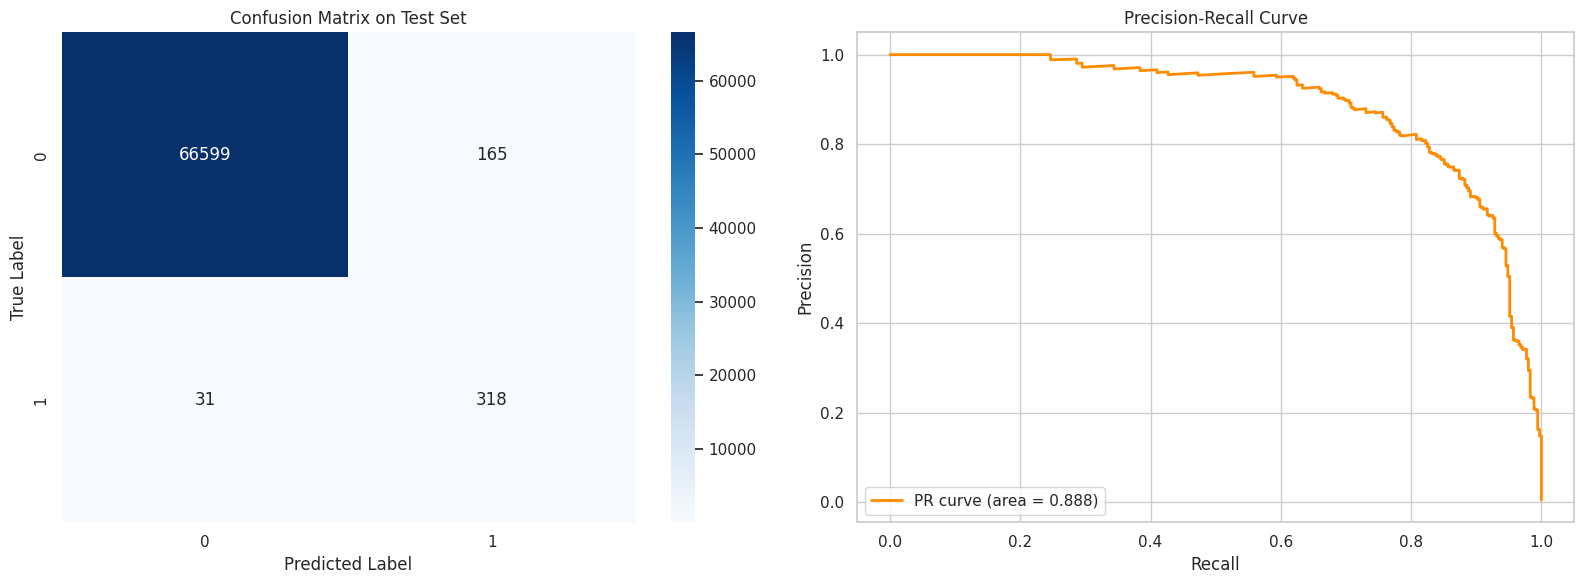

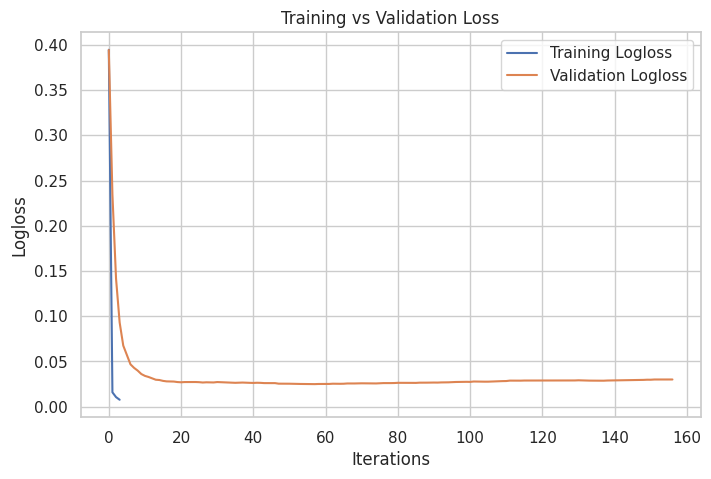

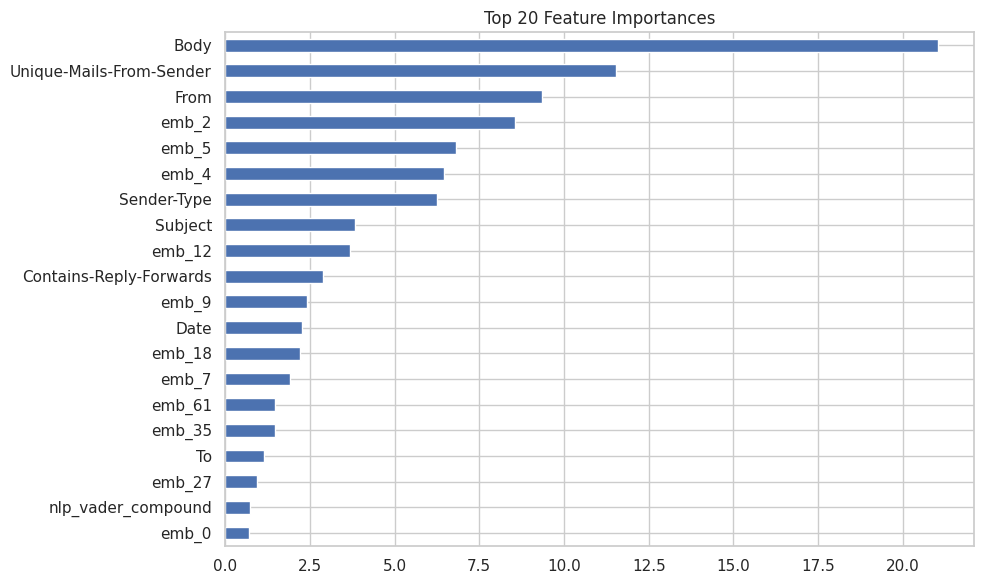


Top 10 features:
Body                        21.044882
Unique-Mails-From-Sender    11.543909
From                         9.341467
emb_2                        8.553466
emb_5                        6.818222
emb_4                        6.460194
Sender-Type                  6.248431
Subject                      3.821046
emb_12                       3.673434
Contains-Reply-Forwards      2.879149
dtype: float64


In [7]:
# ── 8. FINAL METRICS & GRAPHS ─────────────────────────────────────────────────
print("\n--- Final Model Evaluation on Unseen Test Set ---")
y_pred  = [int(p) for p in final_model.predict(test_pool)]
y_proba = final_model.predict_proba(test_pool)[:, 1]

final_f2 = fbeta_score(y_test, y_pred, beta=2.0)
print(f"\nFinal Test F2 Score: {final_f2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix on Test Set')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Precision-Recall Curve
precision, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision)
axes[1].plot(recall_vals, precision, color='darkorange', lw=2,
             label=f'PR curve (area = {pr_auc:0.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

evals_result = final_model.get_evals_result()
metric_key = 'Logloss'
if metric_key in evals_result.get('learn', {}):
    plt.figure(figsize=(8, 5))
    plt.plot(evals_result['learn'][metric_key],      label='Training Logloss')
    plt.plot(evals_result['validation'][metric_key], label='Validation Logloss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Logloss')
    plt.legend()
    plt.show()

# Feature Importance — top 20
fi = pd.Series(
    final_model.get_feature_importance(),
    index=final_model.feature_names_
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(fi.head(10))